# Statistical analysis of background process events generated using MadGraph

We've regenerated all of the background processes using MadGraph5. This should be truly comprehensive, in comparison with the limited Pythia-only approach.

We'll begin by importing some useful packages we use all the time.

In [1]:
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [2]:
from pathlib import Path

import pandas as pd
from tqdm.contrib.concurrent import thread_map

from diquark.config.config_manager import ConfigManager
from diquark.data.loader import DataLoader
from diquark.features.feature_extractor import FeatureExtractor
from diquark.data.preprocessor import Preprocessor

config_files_dir = Path(".").absolute().parent / "diquark" / "config"

def load_data(config_file_path: Path) -> pd.DataFrame:
    assert config_file_path.exists()

    config = ConfigManager(str(config_file_path))

    # Load backgrounds config file
    backgrounds_config_file = config.get_required("data.backgrounds_file")
    backgrounds_config_file_path = (
        config_files_dir / "Backgrounds" / backgrounds_config_file
    )
    backgrounds_config = ConfigManager(backgrounds_config_file_path)

    backgrounds_directory = Path(
        backgrounds_config.get("backgrounds.base_directory", "/")
    )
    backgrounds_file_names = backgrounds_config.get("backgrounds.file_names", {})
    backgrounds_file_name_mapping = backgrounds_config.get(
        "backgrounds.file_name_mapping", {}
    )

    files = set()

    def check_root_file_exists(path: str) -> Path:
        p = Path(path)
        if not p.exists():
            raise Exception(f"Could not find background file at path '{p}'")
        files.add(p)
        return p

    background_path_dict = {
        f"BKG:{key}": check_root_file_exists(path)
        for key, path in backgrounds_file_names.items()
    }
    assert len(files) == len(background_path_dict.keys())

    def find_root_file_by_name(filename: str) -> Path:
        results = backgrounds_directory.glob(f"*{filename}*.root")
        for path in results:
            files.add(path)
            return path
        else:
            raise Exception(
                f"Could not find background file with filename '{filename}'"
            )

    background_path_dict |= {
        f"BKG:{key}": find_root_file_by_name(filename)
        for key, filename in backgrounds_file_name_mapping.items()
    }
    assert len(files) == len(background_path_dict.keys())

    # Load signal config file
    signal_config_file = config.get_required("data.signal_file")
    signal_config_file_path = config_files_dir / "Signals" / signal_config_file
    signal_config = ConfigManager(str(signal_config_file_path))

    signal_file = Path(signal_config.get("signal.file"))
    path_dict = background_path_dict | {"SIG:Suu": signal_file}

    print("Loading data...")
    data_loader = DataLoader(
        path_dict,
        index_start=0,
        index_stop=None,
    )

    data = data_loader.load_data()

    print("Extracting features...")
    feature_extractor = FeatureExtractor(n_jets=32, chi_mass=2000, suu_mass=8000)

    features = thread_map(
        feature_extractor.compute_all,
        data.values(),
        max_workers=32,
        desc="Extracting features",
    )

    # print(f"Working with {len(features[0].keys())} feature columns")

    assert len(features[0].keys()) == len(feature_extractor.feature_names), (
        f"Number of extracted features ({len(features[0].keys())}) doesn't match number of feature names defined on feature extractor object ({len(feature_extractor.feature_names)})"
    )

    datasets = dict(zip(data.keys(), features))

    preprocessor = Preprocessor(config.get("preprocessing", default={}))
    return preprocessor.create_dataframe(datasets)

In [5]:
no_ptj_data = load_data(config_files_dir / "New_Features" / "ATLAS_136_S8000_B7500_32j_5f.yaml")
ptj_100_data = load_data(config_files_dir / "New_Features" / "ATLAS_136_S8000_B7500_ptj_100.yaml")

Loading data...


Loading data:   0%|          | 0/30 [00:00<?, ?it/s]

Extracting features...


Extracting features:   0%|          | 0/30 [00:00<?, ?it/s]

Loading data...


Loading data:   0%|          | 0/30 [00:00<?, ?it/s]

Extracting features...


Extracting features:   0%|          | 0/30 [00:00<?, ?it/s]

In [7]:
no_ptj_data

,jet_multiplicity,p_T_sum,p_T_min,p_T_mean,p_T_stddev,p_T_max,eta_sum,eta_min,eta_mean,eta_stddev,...,chi2_second_component_mean,chi2_second_component_stddev,chi2_second_component_max,chi2_third_component_sum,chi2_third_component_min,chi2_third_component_mean,chi2_third_component_stddev,chi2_third_component_max,Truth,target
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,BKG:gg_bbbar,0
1,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,BKG:gg_bbbar,0
2,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,BKG:gg_bbbar,0
3,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,BKG:gg_bbbar,0
4,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,BKG:gg_bbbar,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,5,3259.083008,50.120354,651.816602,375.098078,1137.367432,-0.856617,-1.838045,-0.171323,1.425062,...,2876.699609,3348.446230,9891.351562,0.000000,0.000000,0.000000,0.000000,0.000000,SIG:Suu,1
2999996,4,7067.077148,763.408203,1766.769287,770.174679,2897.208740,0.559863,-0.636774,0.139966,0.536438,...,7880.687012,4041.542802,13455.291992,0.000000,0.000000,0.000000,0.000000,0.000000,SIG:Suu,1
2999997,6,4879.326660,36.199520,813.221110,775.926442,2208.783936,2.758937,-0.893865,0.459823,0.992267,...,1319.404004,1722.581979,6813.781250,215.114929,215.114929,215.114929,0.028799,215.114929,SIG:Suu,1
2999998,5,5428.678711,47.509563,1085.735742,733.102106,2283.330322,0.293965,-0.788109,0.058793,0.819100,...,4006.294922,4766.251462,13885.993164,0.000000,0.000000,0.000000,0.000000,0.000000,SIG:Suu,1


## Statistical distributions of the events' parameters

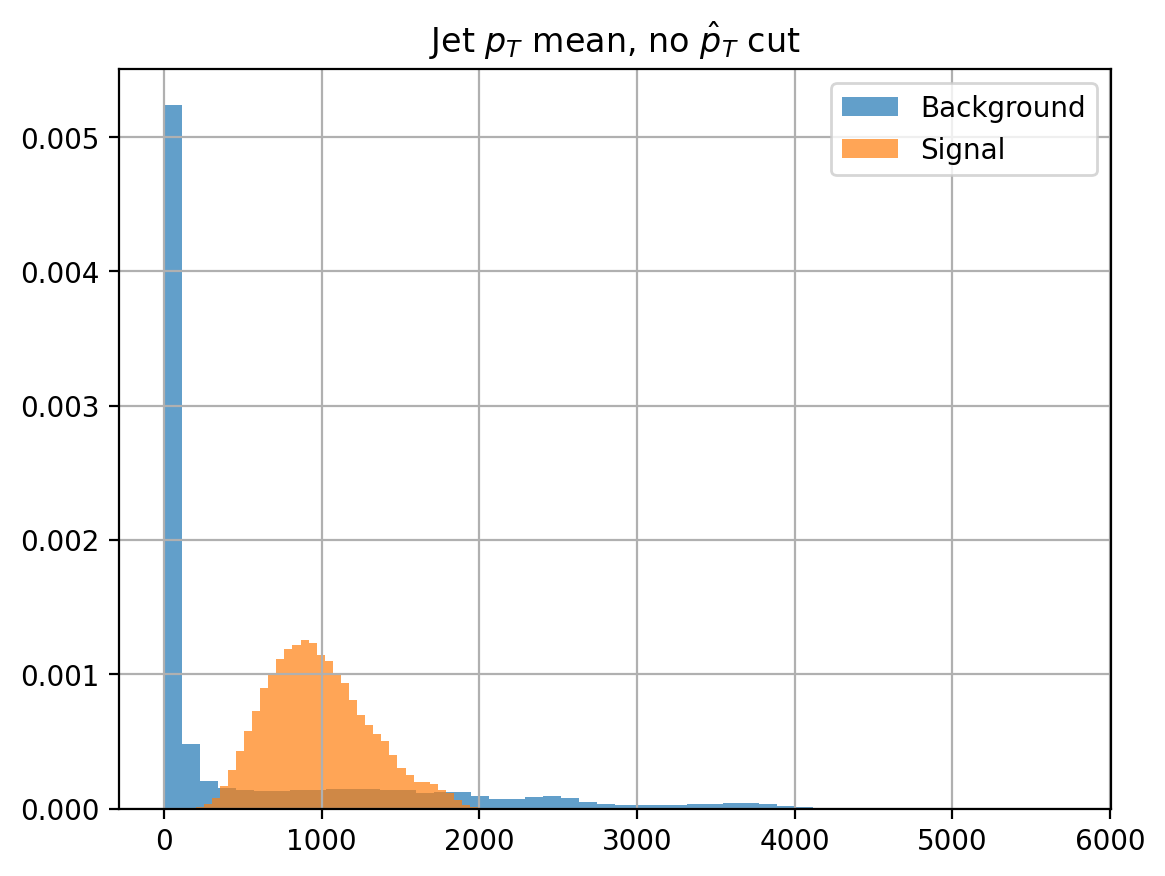

In [22]:
plt.title("Jet $p_T$ mean, no $\\hat{p}_T$ cut")
plt.hist(no_ptj_data[no_ptj_data.target == 0]["p_T_mean"], alpha=0.7, bins=50, density=True, label="Background")
plt.hist(no_ptj_data[no_ptj_data.target == 1]["p_T_mean"], alpha=0.7, bins=50, density=True, label="Signal")
plt.grid()
plt.legend()
plt.show()

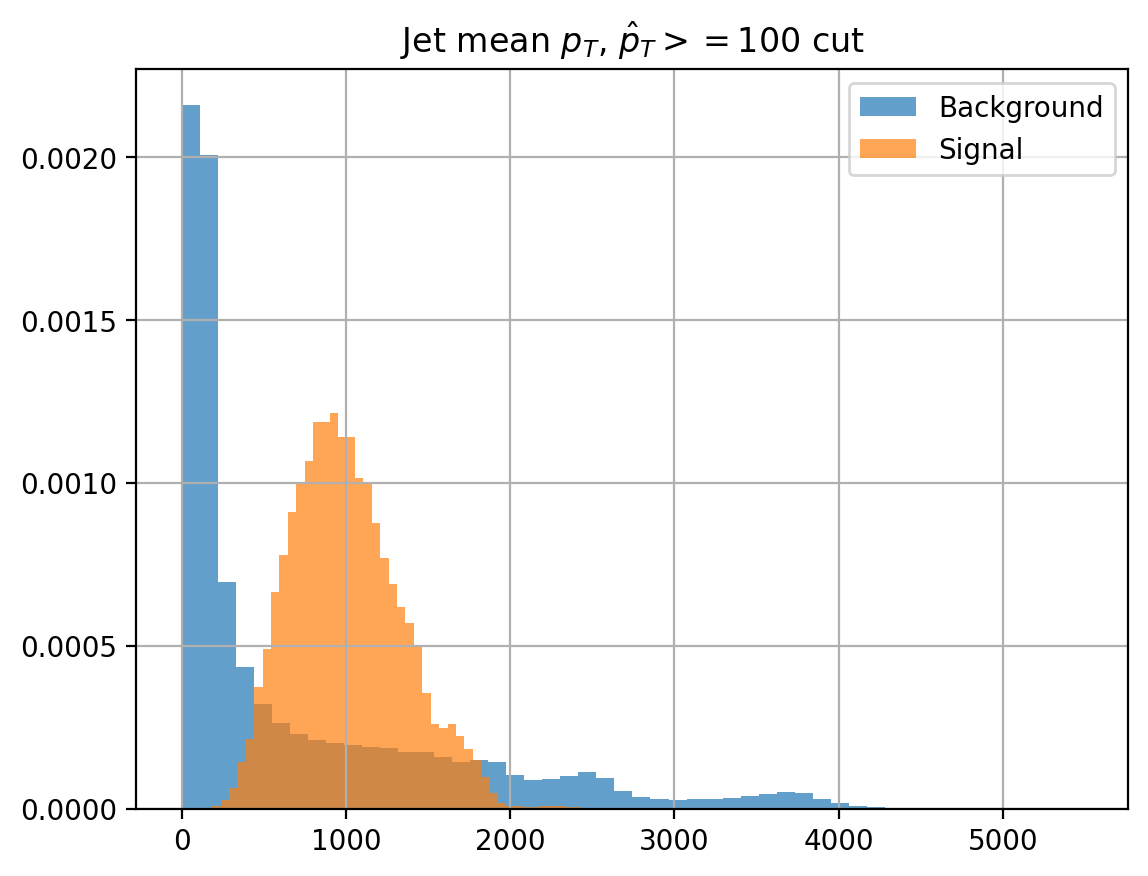

In [23]:
plt.title("Jet mean $p_T$, $\\hat{p}_T >= 100$ cut")
plt.hist(ptj_100_data[ptj_100_data.target == 0]["p_T_mean"], alpha=0.7, bins=50, density=True, label="Background")
plt.hist(ptj_100_data[ptj_100_data.target == 1]["p_T_mean"], alpha=0.7, bins=50, density=True, label="Signal")
plt.grid()
plt.legend()
plt.show()

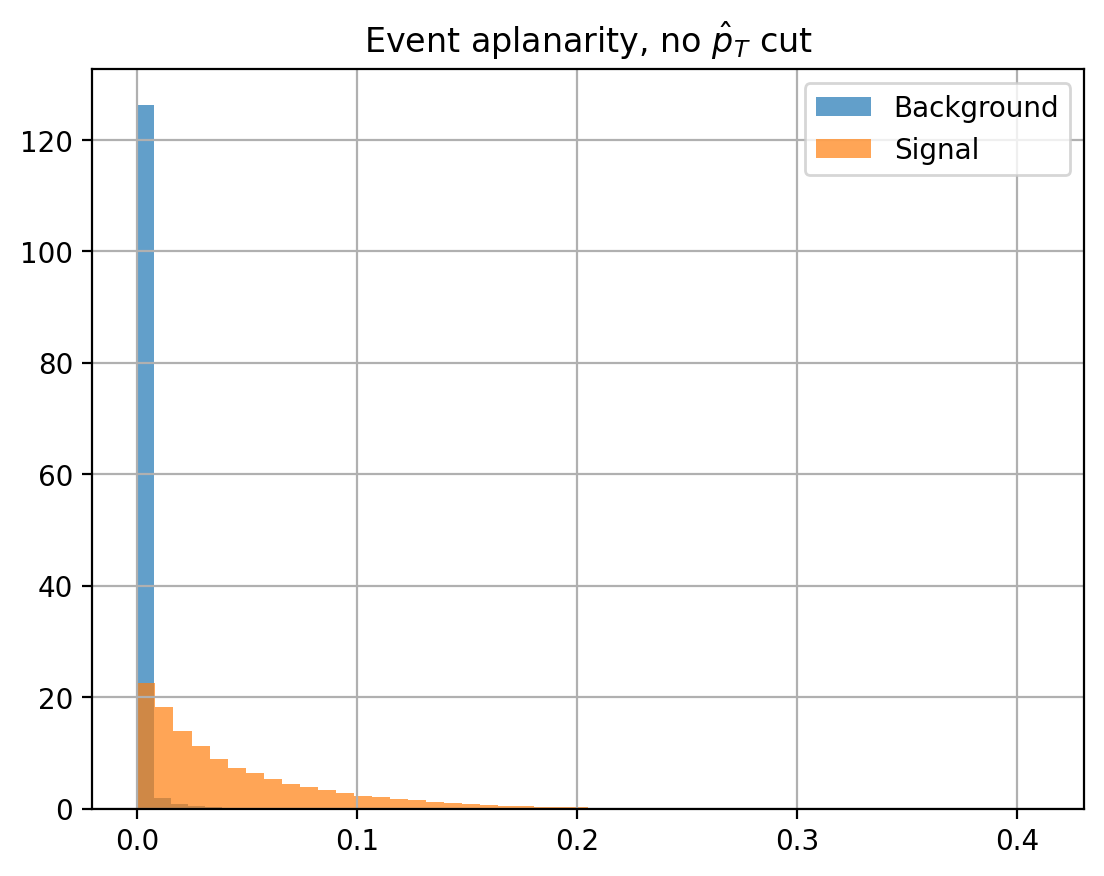

In [27]:
plt.title("Event aplanarity, no $\\hat{p}_T$ cut")
plt.hist(no_ptj_data[no_ptj_data.target == 0]["aplanarity"], alpha=0.7, bins=50, density=True, label="Background")
plt.hist(no_ptj_data[no_ptj_data.target == 1]["aplanarity"], alpha=0.7, bins=50, density=True, label="Signal")
plt.grid()
plt.legend()
plt.show()

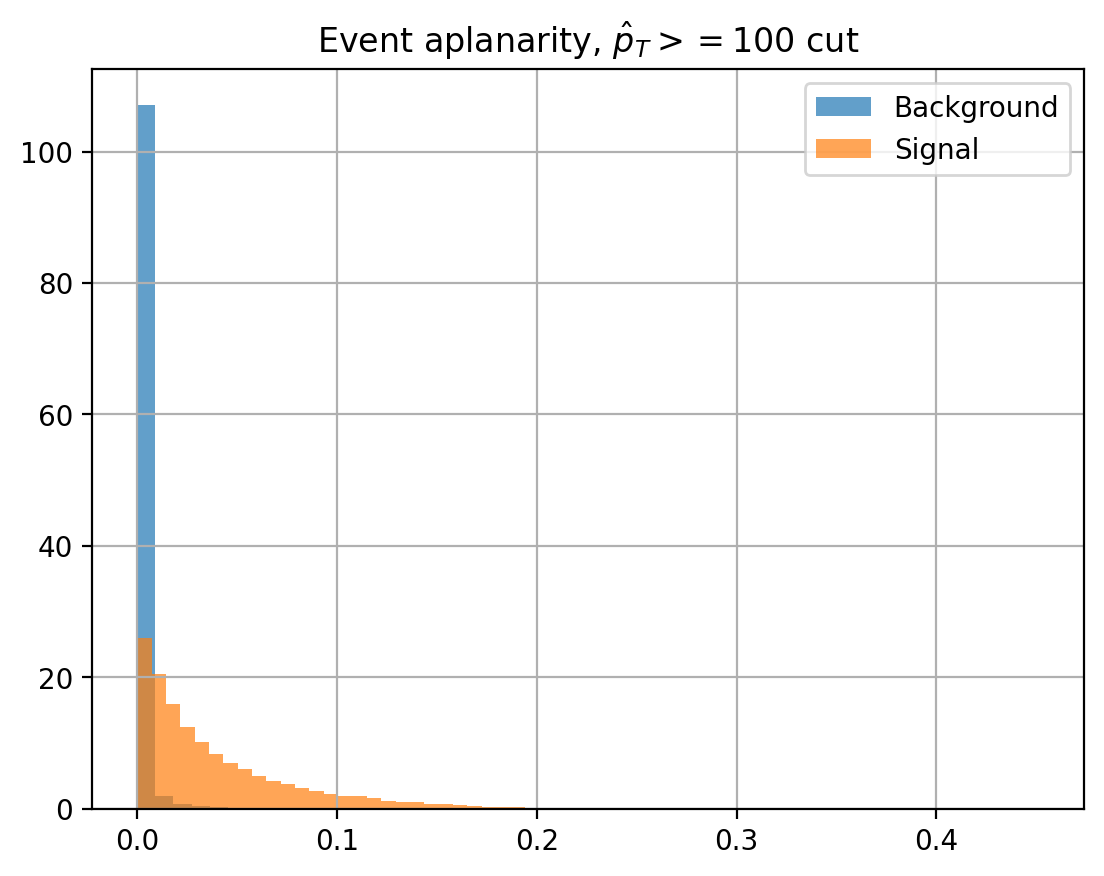

In [28]:
plt.title("Event aplanarity, $\\hat{p}_T >= 100$ cut")
plt.hist(ptj_100_data[ptj_100_data.target == 0]["aplanarity"], alpha=0.7, bins=50, density=True, label="Background")
plt.hist(ptj_100_data[ptj_100_data.target == 1]["aplanarity"], alpha=0.7, bins=50, density=True, label="Signal")
plt.grid()
plt.legend()
plt.show()